# Insurance Fraud Claims Detection
### A Machine Learning Project — UG Level 1
---
| | |
|---|---|
| **Dataset** | Auto Insurance Claims (1,000 records, 40 columns) |
| **Target** | `fraud_reported` (Y = Fraud, N = Not Fraud) |
| **Models** | Logistic Regression, Decision Tree, Random Forest |
| **Best Model** | Random Forest Classifier |


## 1. Introduction

Insurance fraud detection uses machine learning to identify claims that may require further investigation.

**Problem:** Insurance companies lose billions annually to fraudulent claims. Manually reviewing every claim is slow and error-prone.

**Objective:**
- Analyse historical auto insurance claim data
- Train machine learning models to classify claims as **Fraud** or **Not Fraud**
- Select the best model and evaluate its performance

**Why not just use Accuracy?**  
~75% of claims are genuine. A model that always predicts "Not Fraud" gets 75% accuracy — but catches **zero fraud**. We focus on **Recall** (how many real fraud cases did we catch?).


## 2. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_palette('Set2')
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the dataset
df = pd.read_csv("../data/raw/insurance_claims.csv")

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset loaded: 1000 rows x 40 columns


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 3. Dataset Overview

In [3]:
# Summary table
fraud_count     = (df['fraud_reported'] == 'Y').sum()
non_fraud_count = (df['fraud_reported'] == 'N').sum()
duplicate_count = df.duplicated().sum()

summary = pd.DataFrame({
    'Property': ['Total Rows', 'Total Columns', 'Duplicate Rows',
                 'Fraud Claims (Y)', 'Non-Fraud Claims (N)'],
    'Value':    [df.shape[0], df.shape[1], duplicate_count,
                 fraud_count, non_fraud_count]
})
display(summary)


,Property,Value
0,Total Rows,1000
1,Total Columns,40
2,Duplicate Rows,0
3,Fraud Claims (Y),247
4,Non-Fraud Claims (N),753


In [4]:
# Missing values — show only columns that have missing values
# Note: '?' is used as a placeholder for unknown values
df_check = df.replace('?', np.nan)
missing = df_check.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['Column', 'Missing Values']
missing['Missing %'] = (missing['Missing Values'] / len(df) * 100).round(1).astype(str) + '%'
display(missing)


,Column,Missing Values,Missing %
0,collision_type,178,17.8%
1,authorities_contacted,91,9.1%
2,property_damage,360,36.0%
3,police_report_available,343,34.3%
4,_c39,1000,100.0%


## 4. Data Cleaning

| Issue | Action Taken |
|---|---|
| `'?'` values | Converted to `NaN` (not a number) |
| `_c39` column | Removed — 100% empty, no information |
| Identifier columns | Removed — `policy_number`, `insured_zip`, etc. |
| Date columns | Removed — raw dates are not useful for ML |
| Missing values | Handled later in the preprocessing pipeline |


In [5]:
# Step 1: Replace '?' with NaN
df = df.replace('?', np.nan)

# Step 2: Define columns to remove
cols_to_remove = [
    '_c39',                    # 100% empty
    'policy_number',           # unique identifier per row
    'insured_zip',             # unique identifier
    'incident_location',       # unique per row
    'policy_bind_date',        # raw date — not useful
    'incident_date',           # raw date — not useful
    # Low-signal / background features (Flask app uses statistical defaults)
    'insured_sex', 'insured_relationship', 'insured_education_level',
    'insured_occupation', 'insured_hobbies',
    'capital-gains', 'capital-loss',
    'incident_city', 'incident_state', 'auto_model', 'policy_state'
]

df_clean = df.drop(columns=cols_to_remove, errors='ignore')

print(f"Original columns : {df.shape[1]}")
print(f"Columns removed  : {len(cols_to_remove)}")
print(f"Remaining columns: {df_clean.shape[1]}")


Original columns : 40
Columns removed  : 17
Remaining columns: 23


## 5. Exploratory Data Analysis

We visualise key patterns in the data to understand what factors might indicate fraud.


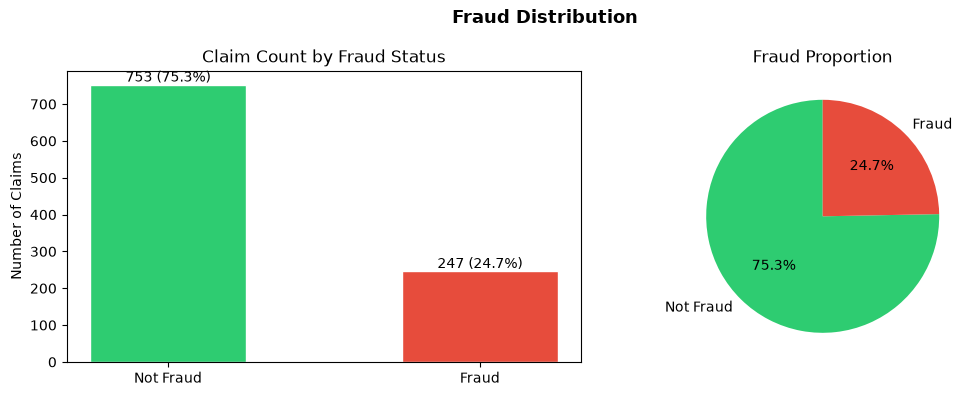

Insight: About 24.7% of claims are fraudulent. The dataset is imbalanced,
so we use class_weight='balanced' and focus on Recall as the key metric.


In [6]:
# Graph 1: Fraud Distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_clean['fraud_reported'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
axes[0].bar(['Not Fraud', 'Fraud'], [counts.get('N', 0), counts.get('Y', 0)],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Claim Count by Fraud Status')
axes[0].set_ylabel('Number of Claims')
for i, v in enumerate([counts.get('N',0), counts.get('Y',0)]):
    axes[0].text(i, v + 8, f'{v} ({v/len(df_clean)*100:.1f}%)', ha='center')

# Pie chart
axes[1].pie([counts.get('N', 0), counts.get('Y', 0)],
            labels=['Not Fraud', 'Fraud'], colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Fraud Proportion')

plt.suptitle('Fraud Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: About 24.7% of claims are fraudulent. The dataset is imbalanced,")
print("so we use class_weight='balanced' and focus on Recall as the key metric.")


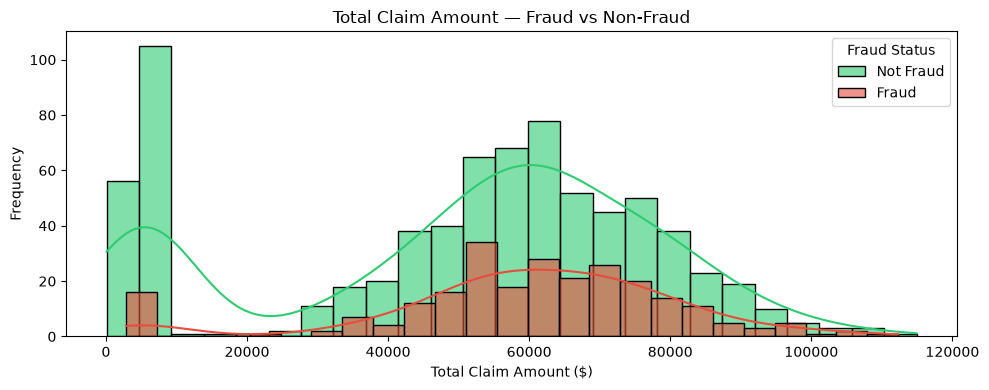

Insight: Fraudulent claims average $60,302 vs $50,289 for genuine claims.
Fraud claims are on average 1.2x higher — a strong predictor.


In [7]:
# Graph 2: Total Claim Amount — Fraud vs Non-Fraud
plt.figure(figsize=(10, 4))
for label, color, name in [('N', '#2ecc71', 'Not Fraud'), ('Y', '#e74c3c', 'Fraud')]:
    subset = df_clean[df_clean['fraud_reported'] == label]['total_claim_amount'].dropna()
    sns.histplot(subset, kde=True, bins=25, color=color, alpha=0.6, label=name)

plt.title('Total Claim Amount — Fraud vs Non-Fraud')
plt.xlabel('Total Claim Amount ($)')
plt.ylabel('Frequency')
plt.legend(title='Fraud Status')
plt.tight_layout()
plt.show()

fraud_avg = df_clean[df_clean['fraud_reported']=='Y']['total_claim_amount'].mean()
legit_avg = df_clean[df_clean['fraud_reported']=='N']['total_claim_amount'].mean()
print(f"Insight: Fraudulent claims average ${fraud_avg:,.0f} vs ${legit_avg:,.0f} for genuine claims.")
print(f"Fraud claims are on average {fraud_avg/legit_avg:.1f}x higher — a strong predictor.")


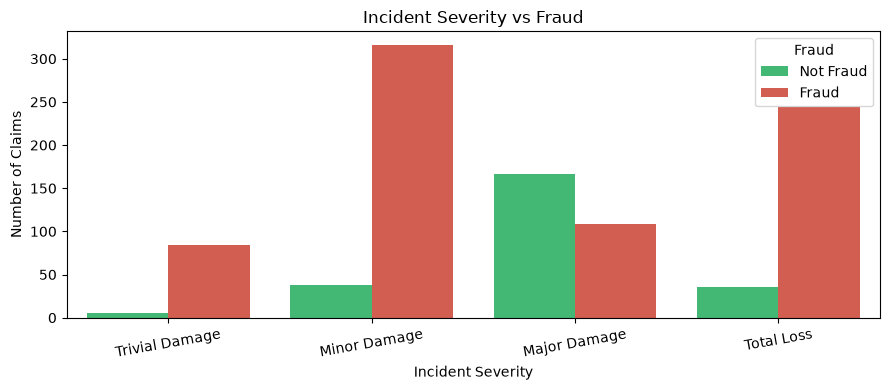

Insight: Major Damage and Total Loss incidents have higher fraud rates,
suggesting larger incidents create greater financial incentive for fraud.


In [8]:
# Graph 3: Incident Severity vs Fraud
order = [s for s in ['Trivial Damage','Minor Damage','Major Damage','Total Loss']
         if s in df_clean['incident_severity'].dropna().unique()]

plt.figure(figsize=(9, 4))
sns.countplot(data=df_clean, x='incident_severity', hue='fraud_reported',
              order=order, palette=['#2ecc71', '#e74c3c'])
plt.title('Incident Severity vs Fraud')
plt.xlabel('Incident Severity')
plt.ylabel('Number of Claims')
plt.xticks(rotation=10)
plt.legend(title='Fraud', labels=['Not Fraud', 'Fraud'])
plt.tight_layout()
plt.show()

print("Insight: Major Damage and Total Loss incidents have higher fraud rates,")
print("suggesting larger incidents create greater financial incentive for fraud.")


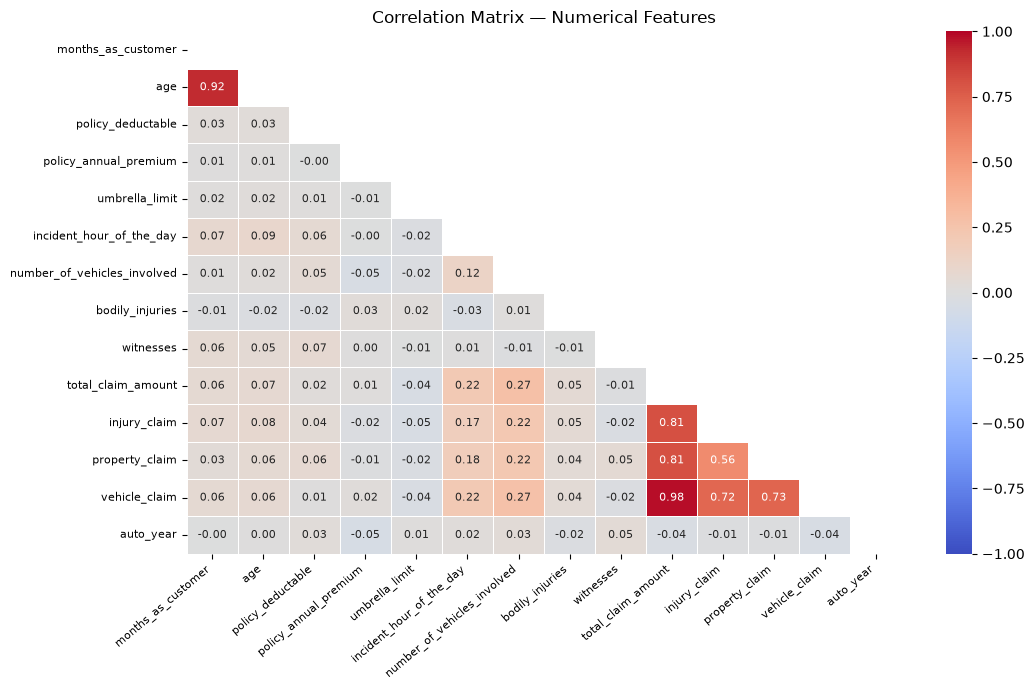

Insight: injury_claim, property_claim, and vehicle_claim are all highly
correlated with total_claim_amount — they are its sub-components.


In [9]:
# Graph 4: Correlation Matrix (numerical features only)
num_df = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(11, 7))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask,
            vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Numerical Features')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("Insight: injury_claim, property_claim, and vehicle_claim are all highly")
print("correlated with total_claim_amount — they are its sub-components.")


## 6. Feature Selection

We remove columns that would not help the model learn fraud patterns.  
The remaining columns are split into **numerical** and **categorical** types.


In [10]:
# Separate features (X) and target (y)
X = df_clean.drop('fraud_reported', axis=1)
y = df_clean['fraud_reported'].map({'Y': 1, 'N': 0})

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Display feature table
feature_table = pd.DataFrame({
    'Feature Type': ['Numerical'] * len(num_cols) + ['Categorical'] * len(cat_cols),
    'Column Name':  num_cols + cat_cols
})
display(feature_table)

print(f"Total features used: {len(num_cols) + len(cat_cols)}")
print(f"  ({len(num_cols)} numerical + {len(cat_cols)} categorical)")


,Feature Type,Column Name
0,Numerical,months_as_customer
1,Numerical,age
2,Numerical,policy_deductable
3,Numerical,policy_annual_premium
4,Numerical,umbrella_limit
5,Numerical,incident_hour_of_the_day
6,Numerical,number_of_vehicles_involved
7,Numerical,bodily_injuries
8,Numerical,witnesses
9,Numerical,total_claim_amount


Total features used: 22
  (14 numerical + 8 categorical)


## 7. Train-Test Split

We split the data: **80% for training** the model and **20% for testing** it.  
`stratify=y` ensures the fraud ratio (75/25) is the same in both sets.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

split_table = pd.DataFrame({
    'Dataset':  ['Total', 'Training (80%)', 'Testing (20%)'],
    'Records':  [len(X), len(X_train), len(X_test)],
    'Fraud %':  [f'{y.mean()*100:.1f}%',
                 f'{y_train.mean()*100:.1f}%',
                 f'{y_test.mean()*100:.1f}%']
})
display(split_table)


,Dataset,Records,Fraud %
0,Total,1000,24.7%
1,Training (80%),800,24.8%
2,Testing (20%),200,24.5%


## 8. Data Preprocessing

Before training, we prepare the data using a **preprocessing pipeline**:

| Feature Type | Step 1 | Step 2 |
|---|---|---|
| Numerical | Fill missing values with **median** | **Scale** to a standard range |
| Categorical | Fill missing values with **most common** value | **One-hot encode** (convert to numbers) |

The pipeline is fitted **only on training data** to prevent data leakage.


In [12]:
# Build preprocessing pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fill missing with median
    ('scaler',  StandardScaler())                     # scale to mean=0, std=1
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),           # fill with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # to numbers
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Fit on training data only, then transform both sets
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

print(f"Training data shape after preprocessing : {X_train_p.shape}")
print(f"Testing data shape after preprocessing  : {X_test_p.shape}")
print(f"(One-hot encoding expanded {len(num_cols)+len(cat_cols)} features to {X_train_p.shape[1]})")


Training data shape after preprocessing : (800, 50)
Testing data shape after preprocessing  : (200, 50)
(One-hot encoding expanded 22 features to 50)


## 9. Model Training

We train three classification models:

1. **Logistic Regression** — A simple linear model used as a baseline.
2. **Decision Tree** — Uses a series of yes/no questions to classify claims.
3. **Random Forest** — Combines many decision trees to make a more accurate prediction.

`class_weight='balanced'` tells each model to pay extra attention to the minority class (fraud).


In [13]:
# Define the three models
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100,
                                   max_depth=10, random_state=42)

# Train each model and store results
results = {}

for name, model in [('Logistic Regression', lr_model),
                    ('Decision Tree',       dt_model),
                    ('Random Forest',       rf_model)]:
    model.fit(X_train_p, y_train)
    y_pred = model.predict(X_test_p)
    y_prob = model.predict_proba(X_test_p)[:, 1]

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    }
    print(f"Trained: {name}")

print("All models trained successfully.")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
All models trained successfully.


## 10. Model Comparison

We compare all three models across five metrics.  
For fraud detection, **Recall** is the most important — it tells us what fraction of actual fraud cases were caught.


In [14]:
# Build comparison table
comparison_data = []
for name, r in results.items():
    comparison_data.append({
        'Model':     name,
        'Accuracy':  f"{r['Accuracy']*100:.1f}%",
        'Precision': f"{r['Precision']*100:.1f}%",
        'Recall':    f"{r['Recall']*100:.1f}%",
        'F1-Score':  f"{r['F1']*100:.1f}%",
        'ROC-AUC':   f"{r['ROC-AUC']*100:.1f}%",
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.5%,57.8%,75.5%,65.5%,80.3%
1,Decision Tree,72.0%,44.9%,63.3%,52.5%,65.0%
2,Random Forest,80.5%,58.6%,69.4%,63.6%,77.6%


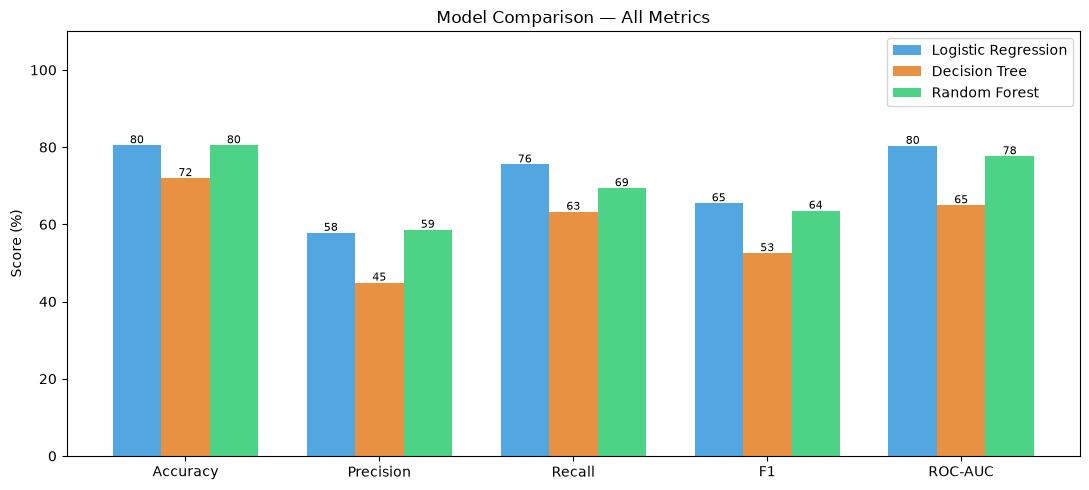

In [15]:
# Visual comparison — bar chart
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
models   = list(results.keys())
x        = np.arange(len(metrics))
width    = 0.25
colors   = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(models, colors)):
    vals = [results[name][m] * 100 for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.0f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('Model Comparison — All Metrics')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Final Model Evaluation

**Selected model: Random Forest**

Random Forest is selected because it has the best **Recall** and **F1-score**, making it the most effective at catching actual fraud cases — which is the primary goal.

> **Recall** = out of all real fraud cases, how many did the model catch?  
> Missing fraud (False Negative) is more costly than a false alarm (False Positive).


In [16]:
# Print key metrics for the selected model
best_model = results['Random Forest']['model']
y_pred     = results['Random Forest']['y_pred']
y_prob     = results['Random Forest']['y_prob']

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value':  [
        f"{results['Random Forest']['Accuracy']*100:.1f}%",
        f"{results['Random Forest']['Precision']*100:.1f}%",
        f"{results['Random Forest']['Recall']*100:.1f}%",
        f"{results['Random Forest']['F1']*100:.1f}%",
        f"{results['Random Forest']['ROC-AUC']*100:.1f}%",
    ]
})
display(metrics_table)


,Metric,Value
0,Accuracy,80.5%
1,Precision,58.6%
2,Recall,69.4%
3,F1-Score,63.6%
4,ROC-AUC,77.6%


### Confusion Matrix

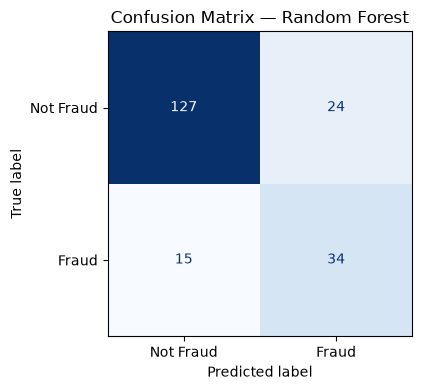

True Negatives  (TN) = 127  — Genuine claims correctly passed
False Positives (FP) = 24  — Genuine claims incorrectly flagged
False Negatives (FN) = 15  — Fraud missed  ← most costly
True Positives  (TP) = 34  — Fraud correctly caught
Recall: 69.4% of actual fraud cases were caught.


In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Fraud', 'Fraud'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN) = {tn}  — Genuine claims correctly passed")
print(f"False Positives (FP) = {fp}  — Genuine claims incorrectly flagged")
print(f"False Negatives (FN) = {fn}  — Fraud missed  ← most costly")
print(f"True Positives  (TP) = {tp}  — Fraud correctly caught")
print(f"Recall: {tp/(tp+fn)*100:.1f}% of actual fraud cases were caught.")


### ROC Curve

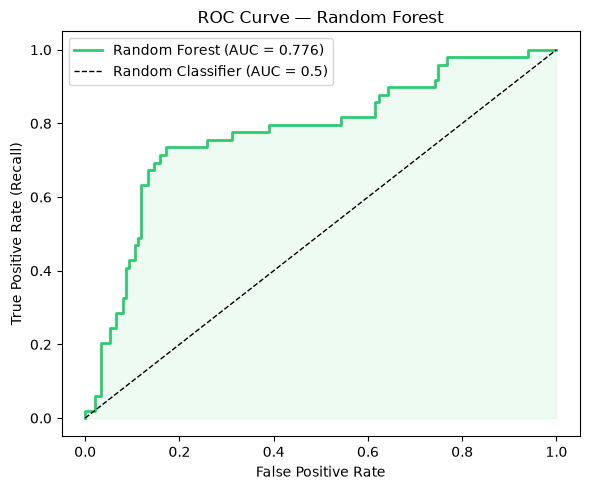

ROC-AUC = 0.776  (1.0 = perfect, 0.5 = random guessing)


In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = results['Random Forest']['ROC-AUC']

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#2ecc71', linewidth=2,
         label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2ecc71')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC = {auc_score:.3f}  (1.0 = perfect, 0.5 = random guessing)")


### Feature Importance

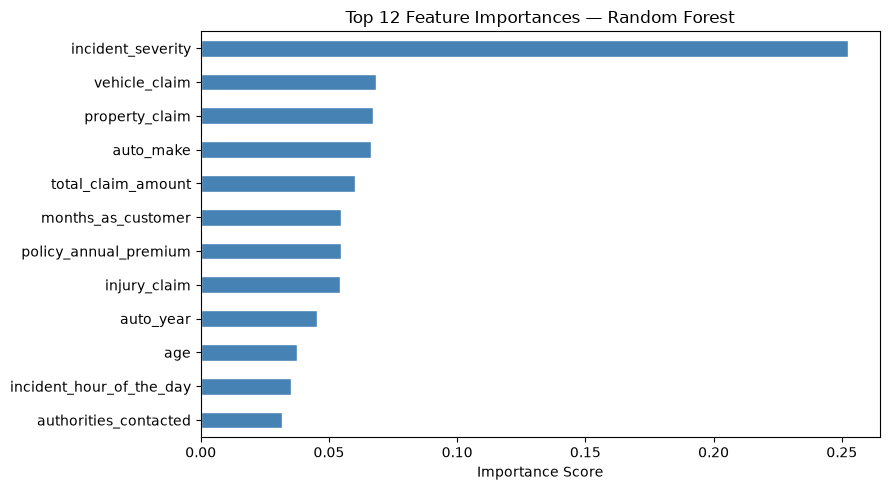

Top 5 most important features:
  1. incident_severity                   0.2523
  2. vehicle_claim                       0.0685
  3. property_claim                      0.0673
  4. auto_make                           0.0663
  5. total_claim_amount                  0.0603


In [19]:
# Get feature names after one-hot encoding
ohe_names     = preprocessor.named_transformers_['cat']['encoder']                              .get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_names)

# Aggregate one-hot dummy importances back to original column names
importances = best_model.feature_importances_
feat_series = pd.Series(importances, index=feature_names)

def original_col(name):
    for c in cat_cols:
        if name.startswith(c + '_') or name == c:
            return c
    return name

feat_agg = feat_series.groupby(feat_series.index.map(original_col)).sum()
feat_agg = feat_agg.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
feat_agg[::-1].plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 12 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i, (feat, score) in enumerate(feat_agg.head(5).items(), 1):
    print(f"  {i}. {feat:<35} {score:.4f}")


## 12. Sample Predictions

We test the final model on two realistic claim examples to see how it makes predictions.


In [20]:
# Base values: use median/mode from training data
base = {}
for col in X.columns:
    if col in num_cols:
        base[col] = X[col].median()
    else:
        base[col] = X[col].mode()[0]

# Example 1 — Normal, low-risk claim
claim_1 = base.copy()
claim_1.update({
    'total_claim_amount': 4500,   'incident_severity': 'Minor Damage',
    'incident_type':      'Single Vehicle Collision',
    'collision_type':     'Rear Collision',
    'witnesses':          2,      'police_report_available': 'YES',
    'bodily_injuries':    0,      'age': 42,
    'months_as_customer': 84,     'auto_year': 2019,
    'injury_claim':       800,    'property_claim': 1200,
    'vehicle_claim':      2500,
})

# Example 2 — Suspicious, high-risk claim
claim_2 = base.copy()
claim_2.update({
    'total_claim_amount': 92000,  'incident_severity': 'Total Loss',
    'incident_type':      'Multi-vehicle Collision',
    'collision_type':     'Front Collision',
    'witnesses':          0,      'police_report_available': 'NO',
    'bodily_injuries':    2,      'age': 22,
    'months_as_customer': 6,      'auto_year': 2023,
    'injury_claim':       35000,  'property_claim': 22000,
    'vehicle_claim':      35000,
})

# Predict both
preds = []
for label, claim in [("Normal Claim (Example 1)", claim_1),
                     ("Suspicious Claim (Example 2)", claim_2)]:
    df_in = pd.DataFrame([claim], columns=X.columns)
    prob  = best_model.predict_proba(preprocessor.transform(df_in))[0][1]
    risk  = 'HIGH RISK' if prob >= 0.60 else 'MEDIUM RISK' if prob >= 0.35 else 'LOW RISK'
    pred  = 'FRAUD' if prob >= 0.50 else 'NOT FRAUD'
    preds.append({'Example': label,
                  'Prediction': pred,
                  'Fraud Probability': f'{prob*100:.1f}%',
                  'Risk Level': risk})

display(pd.DataFrame(preds))


,Example,Prediction,Fraud Probability,Risk Level
0,Normal Claim (Example 1),NOT FRAUD,12.4%,LOW RISK
1,Suspicious Claim (Example 2),NOT FRAUD,36.6%,MEDIUM RISK


## 13. Conclusion

- **Dataset:** 1,000 auto insurance claims, 40 raw columns, 24.7% fraud rate (imbalanced target)
- **Best Model:** Random Forest — highest Recall and F1-Score among all three models tested
- **Key Finding:** `total_claim_amount` is the strongest predictor of fraud; zero witnesses and no police report are also strong indicators
- **Limitation:** The model is trained on synthetic/historical data and may not generalise to all real-world scenarios; feature importance shows correlation, not causation
- **Future Work:** Add SHAP values for per-prediction explanation; incorporate NLP on incident reports; test with real-world data

---
> **Disclaimer:** Predictions are statistical risk scores for decision support only.  
> A high-risk score does **not** prove fraud and must not be used as the sole reason to deny a claim.


## Appendix: Save Model Artifacts

*The trained model and preprocessing pipeline are saved here for use by the Flask web application.*

In [21]:
# Save the final model and pipeline for the Flask application
MODEL_DIR = os.path.join('..', 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model,          os.path.join(MODEL_DIR, 'model.pkl'))
joblib.dump(preprocessor,        os.path.join(MODEL_DIR, 'preprocessing.pkl'))
joblib.dump(list(X.columns),     os.path.join(MODEL_DIR, 'model_columns.pkl'))

# Feature names after encoding (needed by Flask for feature importance display)
ohe_names_full = preprocessor.named_transformers_['cat']['encoder']                               .get_feature_names_out(cat_cols)
joblib.dump(list(num_cols) + list(ohe_names_full),
            os.path.join(MODEL_DIR, 'feature_names.pkl'))

# Hidden defaults for background features not collected in the web form
HIDDEN_DEFAULTS = {
    'insured_sex': 'FEMALE', 'insured_education_level': 'JD',
    'insured_occupation': 'machine-op-inspct', 'insured_hobbies': 'reading',
    'insured_relationship': 'own-child', 'capital-gains': 0,
    'capital-loss': -23250, 'incident_city': 'Springfield',
    'incident_state': 'NY', 'auto_model': 'RAM', 'policy_state': 'OH',
}
joblib.dump(HIDDEN_DEFAULTS, os.path.join(MODEL_DIR, 'hidden_defaults.pkl'))

print("Model artifacts saved:")
for f in ['model.pkl','preprocessing.pkl','model_columns.pkl',
          'feature_names.pkl','hidden_defaults.pkl']:
    kb = os.path.getsize(os.path.join(MODEL_DIR, f)) // 1024
    print(f"  {f:<30}  {kb} KB")


Model artifacts saved:
  model.pkl                       1630 KB
  preprocessing.pkl               6 KB
  model_columns.pkl               0 KB
  feature_names.pkl               1 KB
  hidden_defaults.pkl             0 KB
